In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import scipy.stats as stats

In [2]:
rare_species_definition_threshold = 0.1
rare_species_abundance_threshold = 9.5
expressed_gene_reads_threshold = 2000
number_of_samples_expressed_in_threshold = 21

In [3]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)
raw_transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_for_norm.csv",
    index_col=0,
)

## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### get duplicates and drop the one with higher total genes, so that we can drop everything from the main list
double_duplicates = (
    trimmed_metadata.loc[
        trimmed_metadata.duplicated(
            subset="sampID",
            keep=False,
        )
    ]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_metadata
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_transcriptome
trimmed_raw_transcriptome = raw_transcriptome.loc[trimmed_metadata.index]

In [29]:
trimmed_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time,has_rare_species,lacking_core_species,rare_species_total_abundR100,Dysbiosis Status
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,...,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00,True,False,11.7,Dysbiotic
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,...,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00,True,True,20.8,Dysbiotic
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,...,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00,True,False,34.0,Dysbiotic
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,...,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00,True,True,5.3,Normal
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,...,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00,True,True,16.0,Dysbiotic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,D12,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811.0,383610.0,...,12,6510475.0,Circadian Experiment 1,February,102,2024-02-11 20:00:00,True,False,16.2,Dysbiotic
A2534491401_n01_LICRNA05_E12,E12,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836.0,451686.0,...,12,6178604.0,Circadian Experiment 1,February,102,2024-02-11 04:00:00,True,True,38.0,Dysbiotic
A2534491401_n01_LICRNA05_F12,F12,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375.0,360911.0,...,12,7035335.0,Circadian Experiment 1,February,101,2024-02-10 08:00:00,True,False,8.0,Normal


In [4]:
microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
long_term_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)

In [5]:
species_abundance_table = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/species_core_results.csv"
)
species_abundance_table

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Kordiimonas sp002401685,372,3.661053,3.30,1.000000,True
1,Sphingomonas_L_486704 sp000786205,372,17.954211,15.90,1.000000,True
2,Rhodoferax_C aquaticus,370,4.407143,3.70,0.994624,True
3,Neorhizobium soli,366,3.855080,2.25,0.983871,True
4,Klenkia sp001424455,363,3.581402,2.70,0.975806,True
...,...,...,...,...,...,...
274,Tardiphaga robiniae,1,0.500000,0.50,0.002688,False
275,Telluria timonae,1,10.800000,10.80,0.002688,False
276,UBA4416 sp002420145,1,0.700000,0.70,0.002688,False
277,Umezawaea tangerina,1,1.100000,1.10,0.002688,False


In [6]:
species_abundance_table["rare"] = False
species_abundance_table.loc[
    species_abundance_table["n_samples_present"] <= 37, "rare"
] = True
species_abundance_table

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core,rare
0,Kordiimonas sp002401685,372,3.661053,3.30,1.000000,True,False
1,Sphingomonas_L_486704 sp000786205,372,17.954211,15.90,1.000000,True,False
2,Rhodoferax_C aquaticus,370,4.407143,3.70,0.994624,True,False
3,Neorhizobium soli,366,3.855080,2.25,0.983871,True,False
4,Klenkia sp001424455,363,3.581402,2.70,0.975806,True,False
...,...,...,...,...,...,...,...
274,Tardiphaga robiniae,1,0.500000,0.50,0.002688,False,True
275,Telluria timonae,1,10.800000,10.80,0.002688,False,True
276,UBA4416 sp002420145,1,0.700000,0.70,0.002688,False,True
277,Umezawaea tangerina,1,1.100000,1.10,0.002688,False,True


In [7]:
list_of_rare_species = species_abundance_table.loc[
    species_abundance_table["rare"] == True, "Species"
].tolist()
list_of_core_species = species_abundance_table.loc[
    species_abundance_table["core"] == True, "Species"
].tolist()

In [8]:
# For each sample, check if it has any rare species or is lacking any core species
rare_species_set = set(list_of_rare_species)
core_species_set = set(list_of_core_species)

# Get species present for each sample (using sampID from long_term_microbiome)
sample_species = long_term_microbiome.groupby("sampID")["Species"].apply(set)

# Check if sample has any rare species
has_rare_species = sample_species.apply(lambda x: len(x & rare_species_set) > 0)

# Check if sample is lacking any core species (missing at least one core species)
lacking_core_species = sample_species.apply(lambda x: not core_species_set.issubset(x))

# Total relative abundance of rare species per sample (sum of AbundR100 over rare species)
rare_abund_by_sample = (
    long_term_microbiome.loc[
        long_term_microbiome["Species"].isin(rare_species_set),
        ["sampID", "AbundR100"],
    ]
    .assign(
        AbundR100=lambda d: pd.to_numeric(d["AbundR100"], errors="coerce").fillna(
            0.0
        )  ##Junky column that just makes sure that its numeric
    )
    .groupby("sampID", sort=False)["AbundR100"]
    .sum()
    .rename("rare_species_total_abundR100")
)

# Add columns to metadata using the sampID column (not the index)
trimmed_metadata["has_rare_species"] = (
    trimmed_metadata["sampID"].map(has_rare_species).fillna(False)
)
trimmed_metadata["lacking_core_species"] = (
    trimmed_metadata["sampID"].map(lacking_core_species).fillna(True)
)
trimmed_metadata["rare_species_total_abundR100"] = (
    trimmed_metadata["sampID"].map(rare_abund_by_sample).fillna(0.0)
)

trimmed_metadata[
    [
        "sampID",
        "has_rare_species",
        "lacking_core_species",
        "rare_species_total_abundR100",
    ]
]

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_31270/284639656.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trimmed_metadata["sampID"].map(has_rare_species).fillna(False)
/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_31270/284639656.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trimmed_metadata["sampID"].map(lacking_core_species).fillna(True)


,sampID,has_rare_species,lacking_core_species,rare_species_total_abundR100
filename,,,,
A2450525897_n01_LICRNA01_A01,LIC001,True,False,11.7
A2450525897_n01_LICRNA01_B01,LIC002,True,True,20.8
A2450525897_n01_LICRNA01_C01,LIC003,True,False,34.0
A2450525897_n01_LICRNA01_E01,LIC005,True,True,5.3
A2450525897_n01_LICRNA01_F01,LIC006,True,True,16.0
...,...,...,...,...
A2534491401_n01_LICRNA05_D12,LIC542,True,False,16.2
A2534491401_n01_LICRNA05_E12,LIC495,True,True,38.0
A2534491401_n01_LICRNA05_F12,LIC421,True,False,8.0


In [9]:
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,4.944011,1.397952,0.0,5.994827,5.876072,0.0,0.0,58.062147,0.0,15.150509,...,0.000000,13.256631,0.000000,0.938539,0.0,0.0,0.956942,0.0,0.000000,1.597223
A2450525897_n01_LICRNA01_B01,2.911492,4.379655,0.0,2.665837,3.261267,0.0,0.0,57.934612,0.0,10.439273,...,0.000000,13.734068,0.000000,0.350043,0.0,0.0,0.166556,0.0,0.000000,2.184266
A2450525897_n01_LICRNA01_C01,6.270921,9.657724,0.0,0.000000,4.158376,0.0,0.0,38.161651,0.0,10.623477,...,34.304262,31.001035,0.000000,0.000000,0.0,0.0,0.051248,0.0,0.000000,0.855379
A2450525897_n01_LICRNA01_E01,3.690795,5.635420,0.0,3.786748,2.141076,0.0,0.0,37.996762,0.0,8.530523,...,0.000000,9.676399,0.000000,0.000000,0.0,0.0,0.142875,0.0,0.000000,1.987260
A2450525897_n01_LICRNA01_F01,2.781737,8.695001,0.0,2.016710,8.565957,0.0,0.0,64.854957,0.0,16.845214,...,0.000000,67.280011,0.000000,0.000000,0.0,0.0,0.496000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,0.0,7.860235,3.199519,0.0,0.0,39.201659,0.0,1.057777,...,0.000000,4.602930,22.529946,1.333133,0.0,0.0,0.036247,0.0,4.867353,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,0.0,1.577446,3.055581,0.0,0.0,29.564231,0.0,12.872063,...,0.000000,6.899039,1.605254,3.951394,0.0,0.0,0.839348,0.0,0.000000,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,0.0,1.641699,5.632121,0.0,0.0,48.940407,0.0,24.612749,...,0.000000,7.502750,0.000000,1.799150,0.0,0.0,0.000000,0.0,0.000000,0.145801


In [10]:
trimmed_transcriptome = trimmed_transcriptome.dropna(how="all", axis=0)
trimmed_transcriptome = trimmed_transcriptome.dropna(how="all", axis=1)

In [11]:
### Remove outlier identifed
trimmed_transcriptome = trimmed_transcriptome.drop(index="A2534491401_n01_LICRNA05_A10")
trimmed_metadata = trimmed_metadata.drop(index="A2534491401_n01_LICRNA05_A10")
trimmed_transcriptome = trimmed_transcriptome.drop(index="A2534491401_n01_LICRNA05_A09")
trimmed_metadata = trimmed_metadata.drop(index="A2534491401_n01_LICRNA05_A09")

In [12]:
pca = sklearn.decomposition.PCA(n_components=5).fit_transform(trimmed_transcriptome)
pca

array([[-110436.79525524,  -58882.28811264,   -1952.06332902,
          21362.38994803,   -3469.06851829],
       [-131473.97496125,  -16522.9744646 ,  -12456.79260349,
          18068.42457773,   -7280.05149753],
       [-135692.25380761,  -61353.02663578,  -17848.45515269,
           4084.83228308,   -9289.10285305],
       ...,
       [  13538.92829182,  -49037.21423427,    1652.17227473,
          -3845.06556806,   -1791.4167652 ],
       [-110856.83969965,  -21814.37171526,   13263.54981151,
         -10585.30074075,   20898.62582732],
       [ -58911.00283244,   24083.02032912,   24694.15583667,
          -4256.96972926,    9208.23548142]], shape=(430, 5))

In [13]:
trimmed_metadata["Dysbiosis Status"] = "Normal"
trimmed_metadata.loc[
    (
        trimmed_metadata["rare_species_total_abundR100"]
        > rare_species_abundance_threshold
    ),
    "Dysbiosis Status",
] = "Dysbiotic"

In [14]:
trimmed_metadata.columns

Index(['plate.pos', 'sampID', 'sample.type', 'timepoint', 'date', 'time',
       'extractplate', 'rnaprepplate', 'Unmapped', 'No Feature', 'plate_row',
       'plate_col', 'Total Reads', 'Experiment Type', 'Sample Month',
       'daysincestart', 'Date and Time', 'has_rare_species',
       'lacking_core_species', 'rare_species_total_abundR100',
       'Dysbiosis Status'],
      dtype='object')

(array([-150000., -100000.,  -50000.,       0.,   50000.,  100000.,
         150000.]),
 [Text(0, -150000.0, '−150000'),
  Text(0, -100000.0, '−100000'),
  Text(0, -50000.0, '−50000'),
  Text(0, 0.0, '0'),
  Text(0, 50000.0, '50000'),
  Text(0, 100000.0, '100000'),
  Text(0, 150000.0, '150000')])

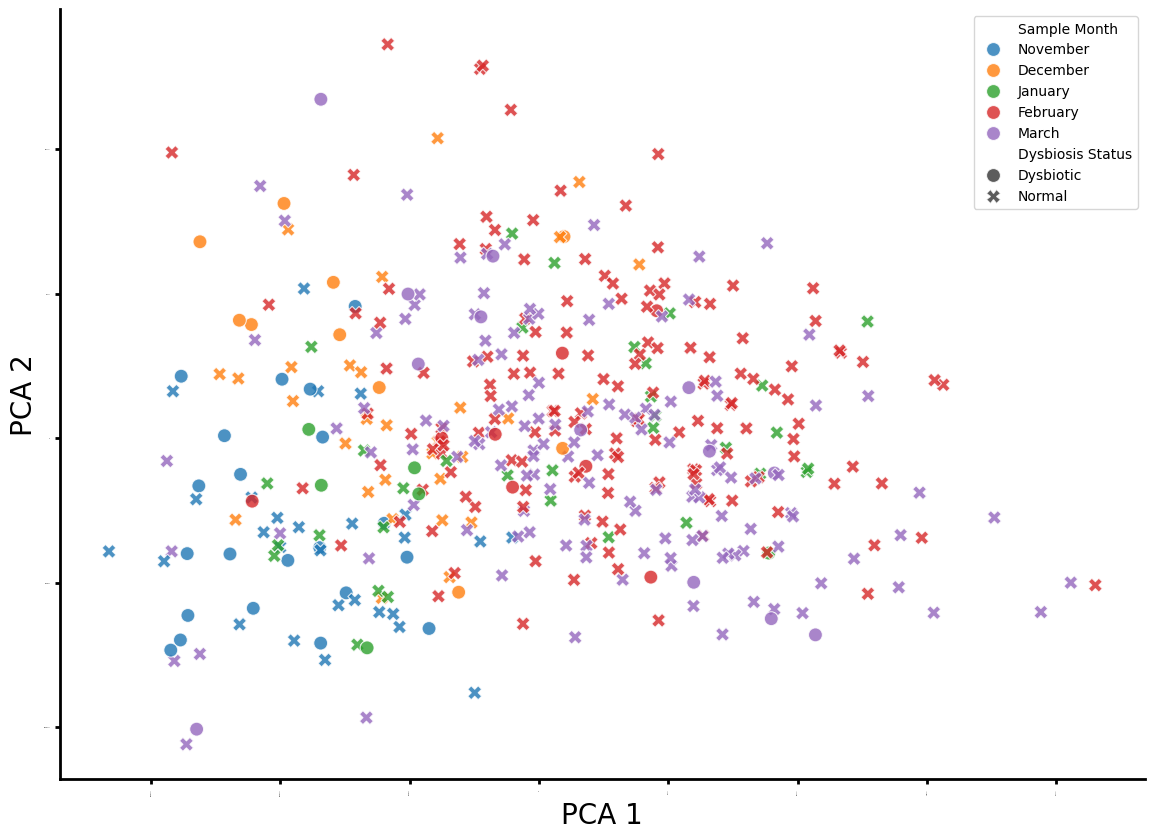

In [15]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=pca[:, 0],
    y=pca[:, 1],
    style=trimmed_metadata["Dysbiosis Status"],
    hue=trimmed_metadata["Sample Month"],
    s=100,
    alpha=0.8,
)
plt.xlabel("PCA 1", fontsize=20)
plt.ylabel("PCA 2", fontsize=20)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

# plt.ylim(0,10)

(array([-150000., -100000.,  -50000.,       0.,   50000.,  100000.,
         150000.]),
 [Text(0, -150000.0, '−150000'),
  Text(0, -100000.0, '−100000'),
  Text(0, -50000.0, '−50000'),
  Text(0, 0.0, '0'),
  Text(0, 50000.0, '50000'),
  Text(0, 100000.0, '100000'),
  Text(0, 150000.0, '150000')])

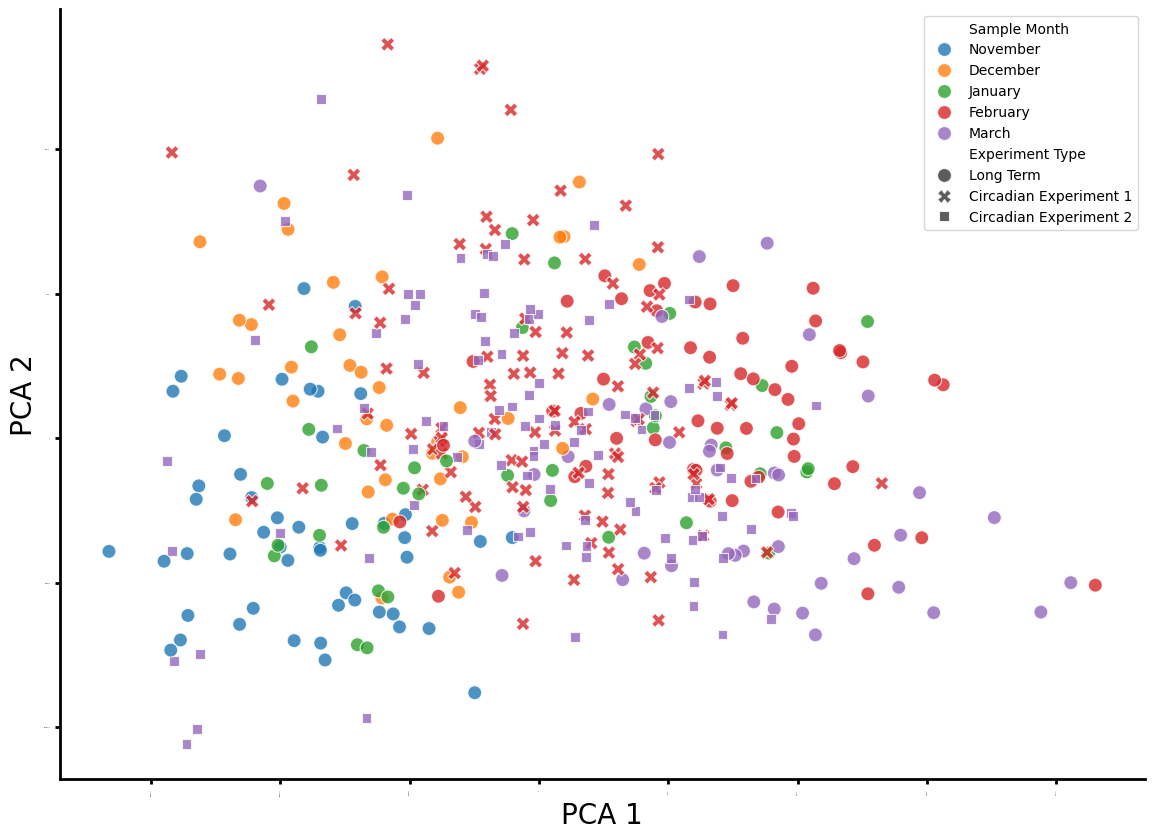

In [46]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=pca[:, 0],
    y=pca[:, 1],
    style=trimmed_metadata["Experiment Type"],
    hue=trimmed_metadata["Sample Month"],
    s=100,
    alpha=0.8,
)
plt.xlabel("PCA 1", fontsize=20)
plt.ylabel("PCA 2", fontsize=20)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

# plt.ylim(0,10)

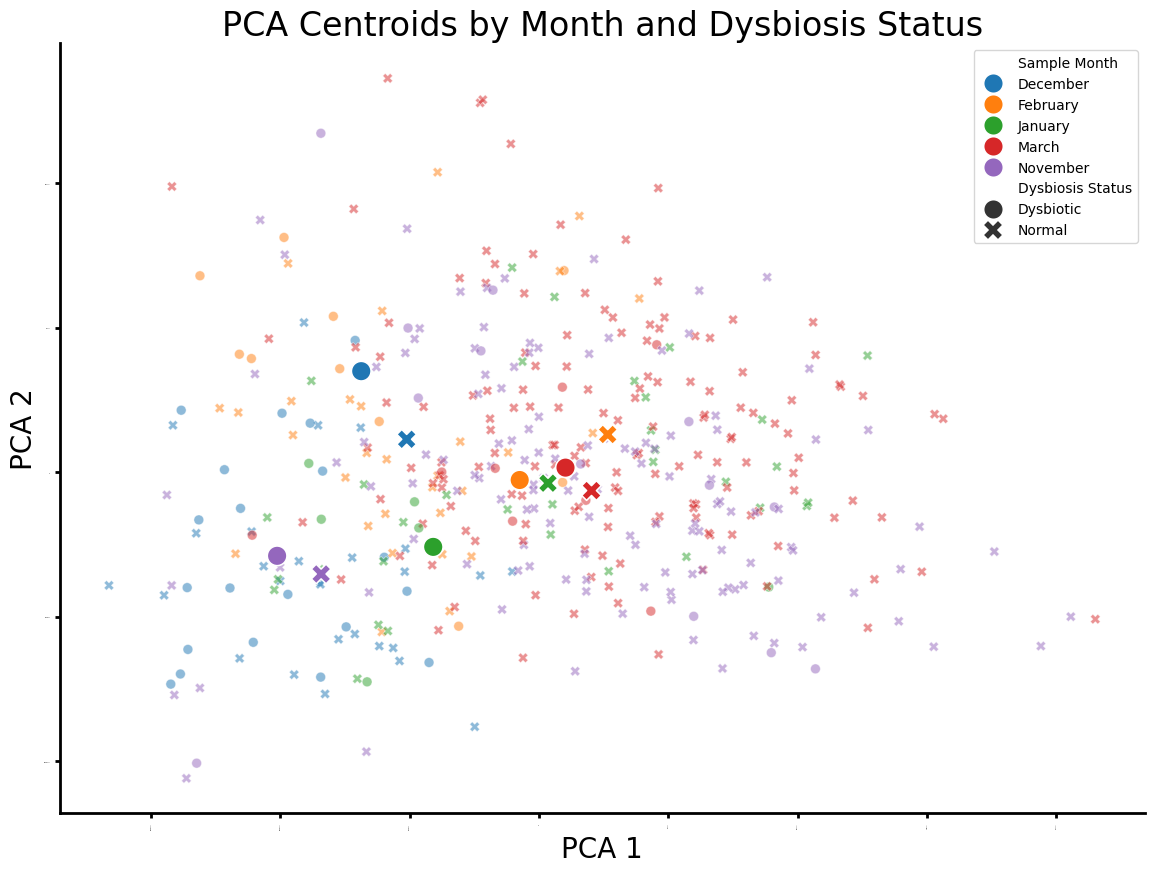

In [16]:
pca_df = pd.DataFrame(
    pca[:, :2], columns=["PCA 1", "PCA 2"], index=trimmed_metadata.index
)
pca_df["Sample Month"] = trimmed_metadata["Sample Month"]
pca_df["Dysbiosis Status"] = trimmed_metadata["Dysbiosis Status"]

centroids = pca_df.groupby(["Sample Month", "Dysbiosis Status"]).mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")

# Plot background points
sns.scatterplot(
    x=pca[:, 0],
    y=pca[:, 1],
    style=trimmed_metadata["Dysbiosis Status"],
    hue=trimmed_metadata["Sample Month"],
    s=50,
    alpha=0.5,
    ax=ax,
    legend=False,
)

# Plot centroids
sns.scatterplot(
    data=centroids,
    x="PCA 1",
    y="PCA 2",
    style="Dysbiosis Status",
    hue="Sample Month",
    s=200,
    alpha=1.0,
    ax=ax,
)

plt.xlabel("PCA 1", fontsize=20)
plt.ylabel("PCA 2", fontsize=20)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.legend(loc="upper right")
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
plt.title("PCA Centroids by Month and Dysbiosis Status", fontsize=24)
plt.show()

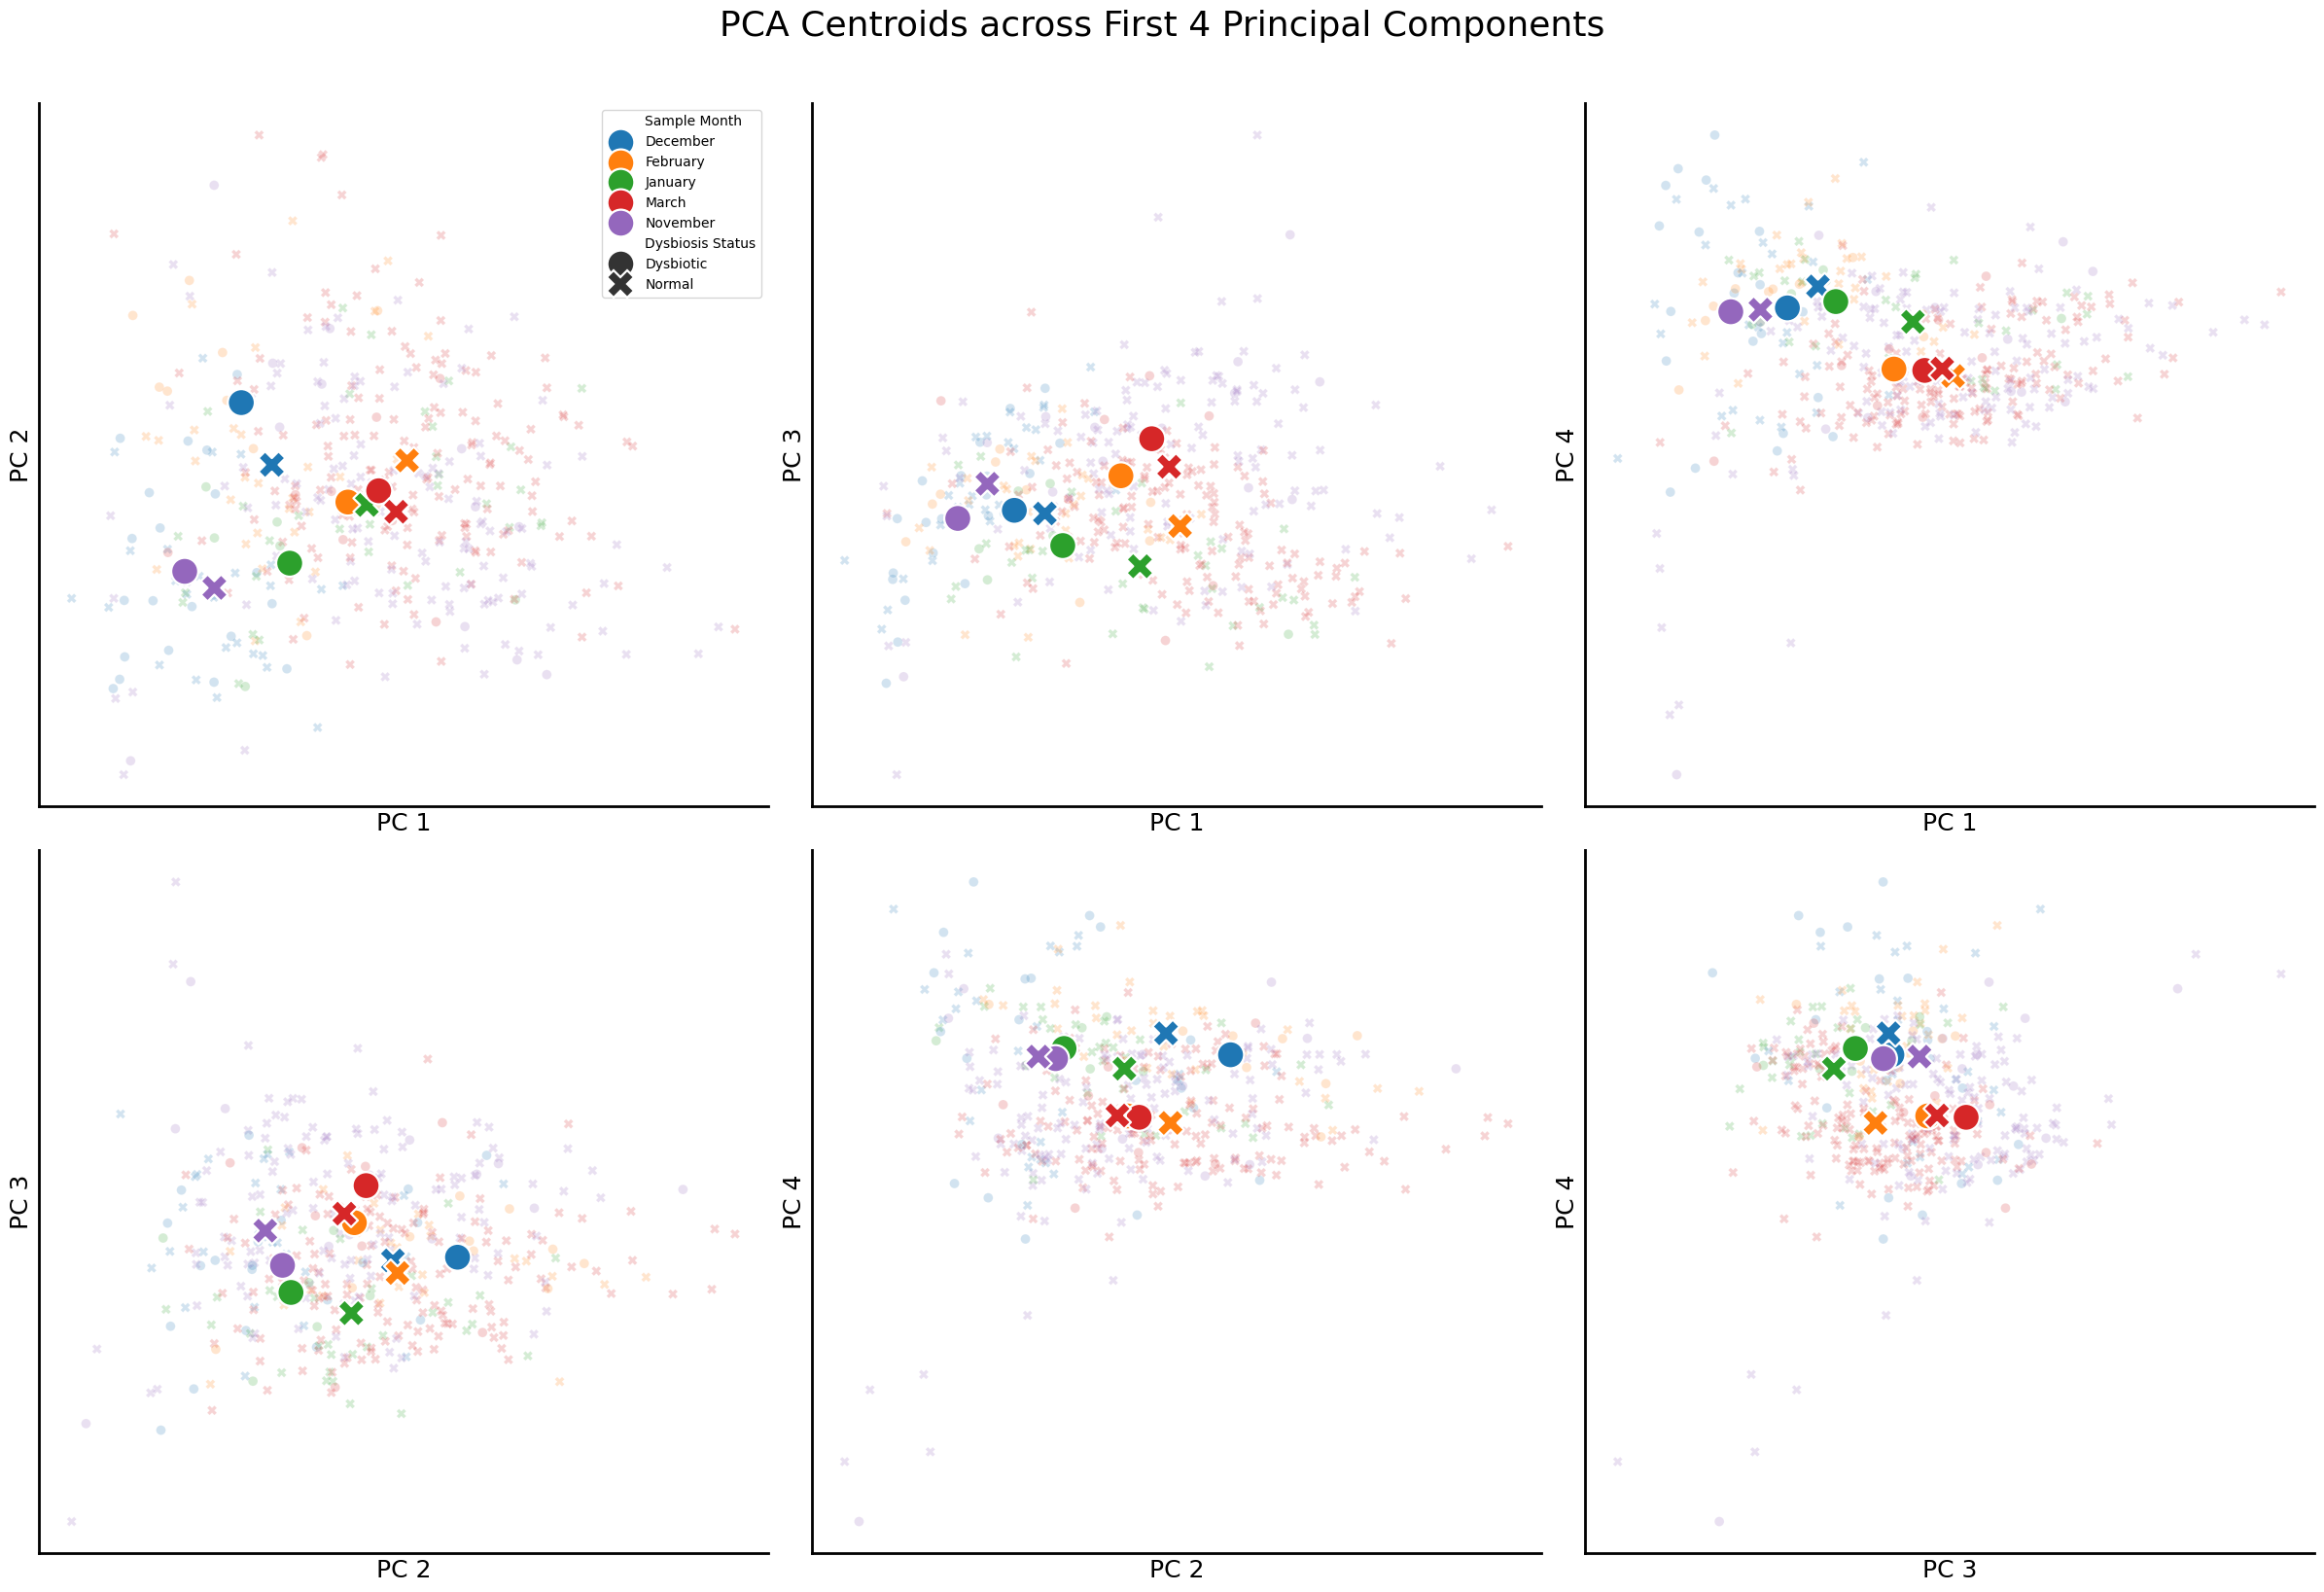

In [17]:
pca_df_multi = pd.DataFrame(
    pca[:, :4], columns=["PC 1", "PC 2", "PC 3", "PC 4"], index=trimmed_metadata.index
)
pca_df_multi["Sample Month"] = trimmed_metadata["Sample Month"]
pca_df_multi["Dysbiosis Status"] = trimmed_metadata["Dysbiosis Status"]

centroids_multi = (
    pca_df_multi.groupby(["Sample Month", "Dysbiosis Status"]).mean().reset_index()
)

pairs = [(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.patch.set_facecolor("white")
axes = axes.flatten()

for i, (pc_x, pc_y) in enumerate(pairs):
    ax = axes[i]
    col_x = f"PC {pc_x}"
    col_y = f"PC {pc_y}"

    # Plot background points
    sns.scatterplot(
        data=pca_df_multi,
        x=col_x,
        y=col_y,
        style="Dysbiosis Status",
        hue="Sample Month",
        s=50,
        alpha=0.2,
        ax=ax,
        legend=False,
    )

    # Plot centroids
    sns.scatterplot(
        data=centroids_multi,
        x=col_x,
        y=col_y,
        style="Dysbiosis Status",
        hue="Sample Month",
        s=400,
        alpha=1.0,
        ax=ax,
        legend=(i == 0),  # Only add legend to the first subplot to prevent clutter
    )

    ax.set_xlabel(col_x, fontsize=18)
    ax.set_ylabel(col_y, fontsize=18)
    sns.despine(ax=ax)
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(2)
    ax.tick_params(axis="both", width=2)
    ax.set_xticks([])  # Remove tick labels for a cleaner look
    ax.set_yticks([])

plt.suptitle("PCA Centroids across First 4 Principal Components", fontsize=26, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
import plotly.express as px

# Create a dataframe for interactive plotting, taking useful metadata for hover
interactive_df = pca_df.copy()
interactive_df["filename"] = interactive_df.index
interactive_df["sampID"] = trimmed_metadata["sampID"]
interactive_df["plate.pos"] = trimmed_metadata["plate.pos"]
interactive_df["Experiment Type"] = trimmed_metadata["Experiment Type"]

# Plot using plotly
fig = px.scatter(
    interactive_df,
    x="PCA 1",
    y="PCA 2",
    color="Sample Month",
    symbol="Dysbiosis Status",
    hover_data=["filename", "sampID", "plate.pos", "Experiment Type"],
    title="Interactive PCA 1 vs PCA 2",
    width=1000,
    height=800,
)

fig.update_traces(marker=dict(size=8, opacity=0.8))
fig.show()

In [19]:
# Create an interactive plot for PC 2 vs PC 3
interactive_df_23 = pca_df_multi.copy()
interactive_df_23["filename"] = interactive_df_23.index
interactive_df_23["sampID"] = trimmed_metadata["sampID"]
interactive_df_23["plate.pos"] = trimmed_metadata["plate.pos"]
interactive_df_23["Experiment Type"] = trimmed_metadata["Experiment Type"]

fig2 = px.scatter(
    interactive_df_23,
    x="PC 2",
    y="PC 3",
    color="Sample Month",
    symbol="Dysbiosis Status",
    hover_data=["filename", "sampID", "plate.pos", "Experiment Type"],
    title="Interactive PC 2 vs PC 3",
    width=1000,
    height=800,
)

fig2.update_traces(marker=dict(size=8, opacity=0.8))
fig2.show()

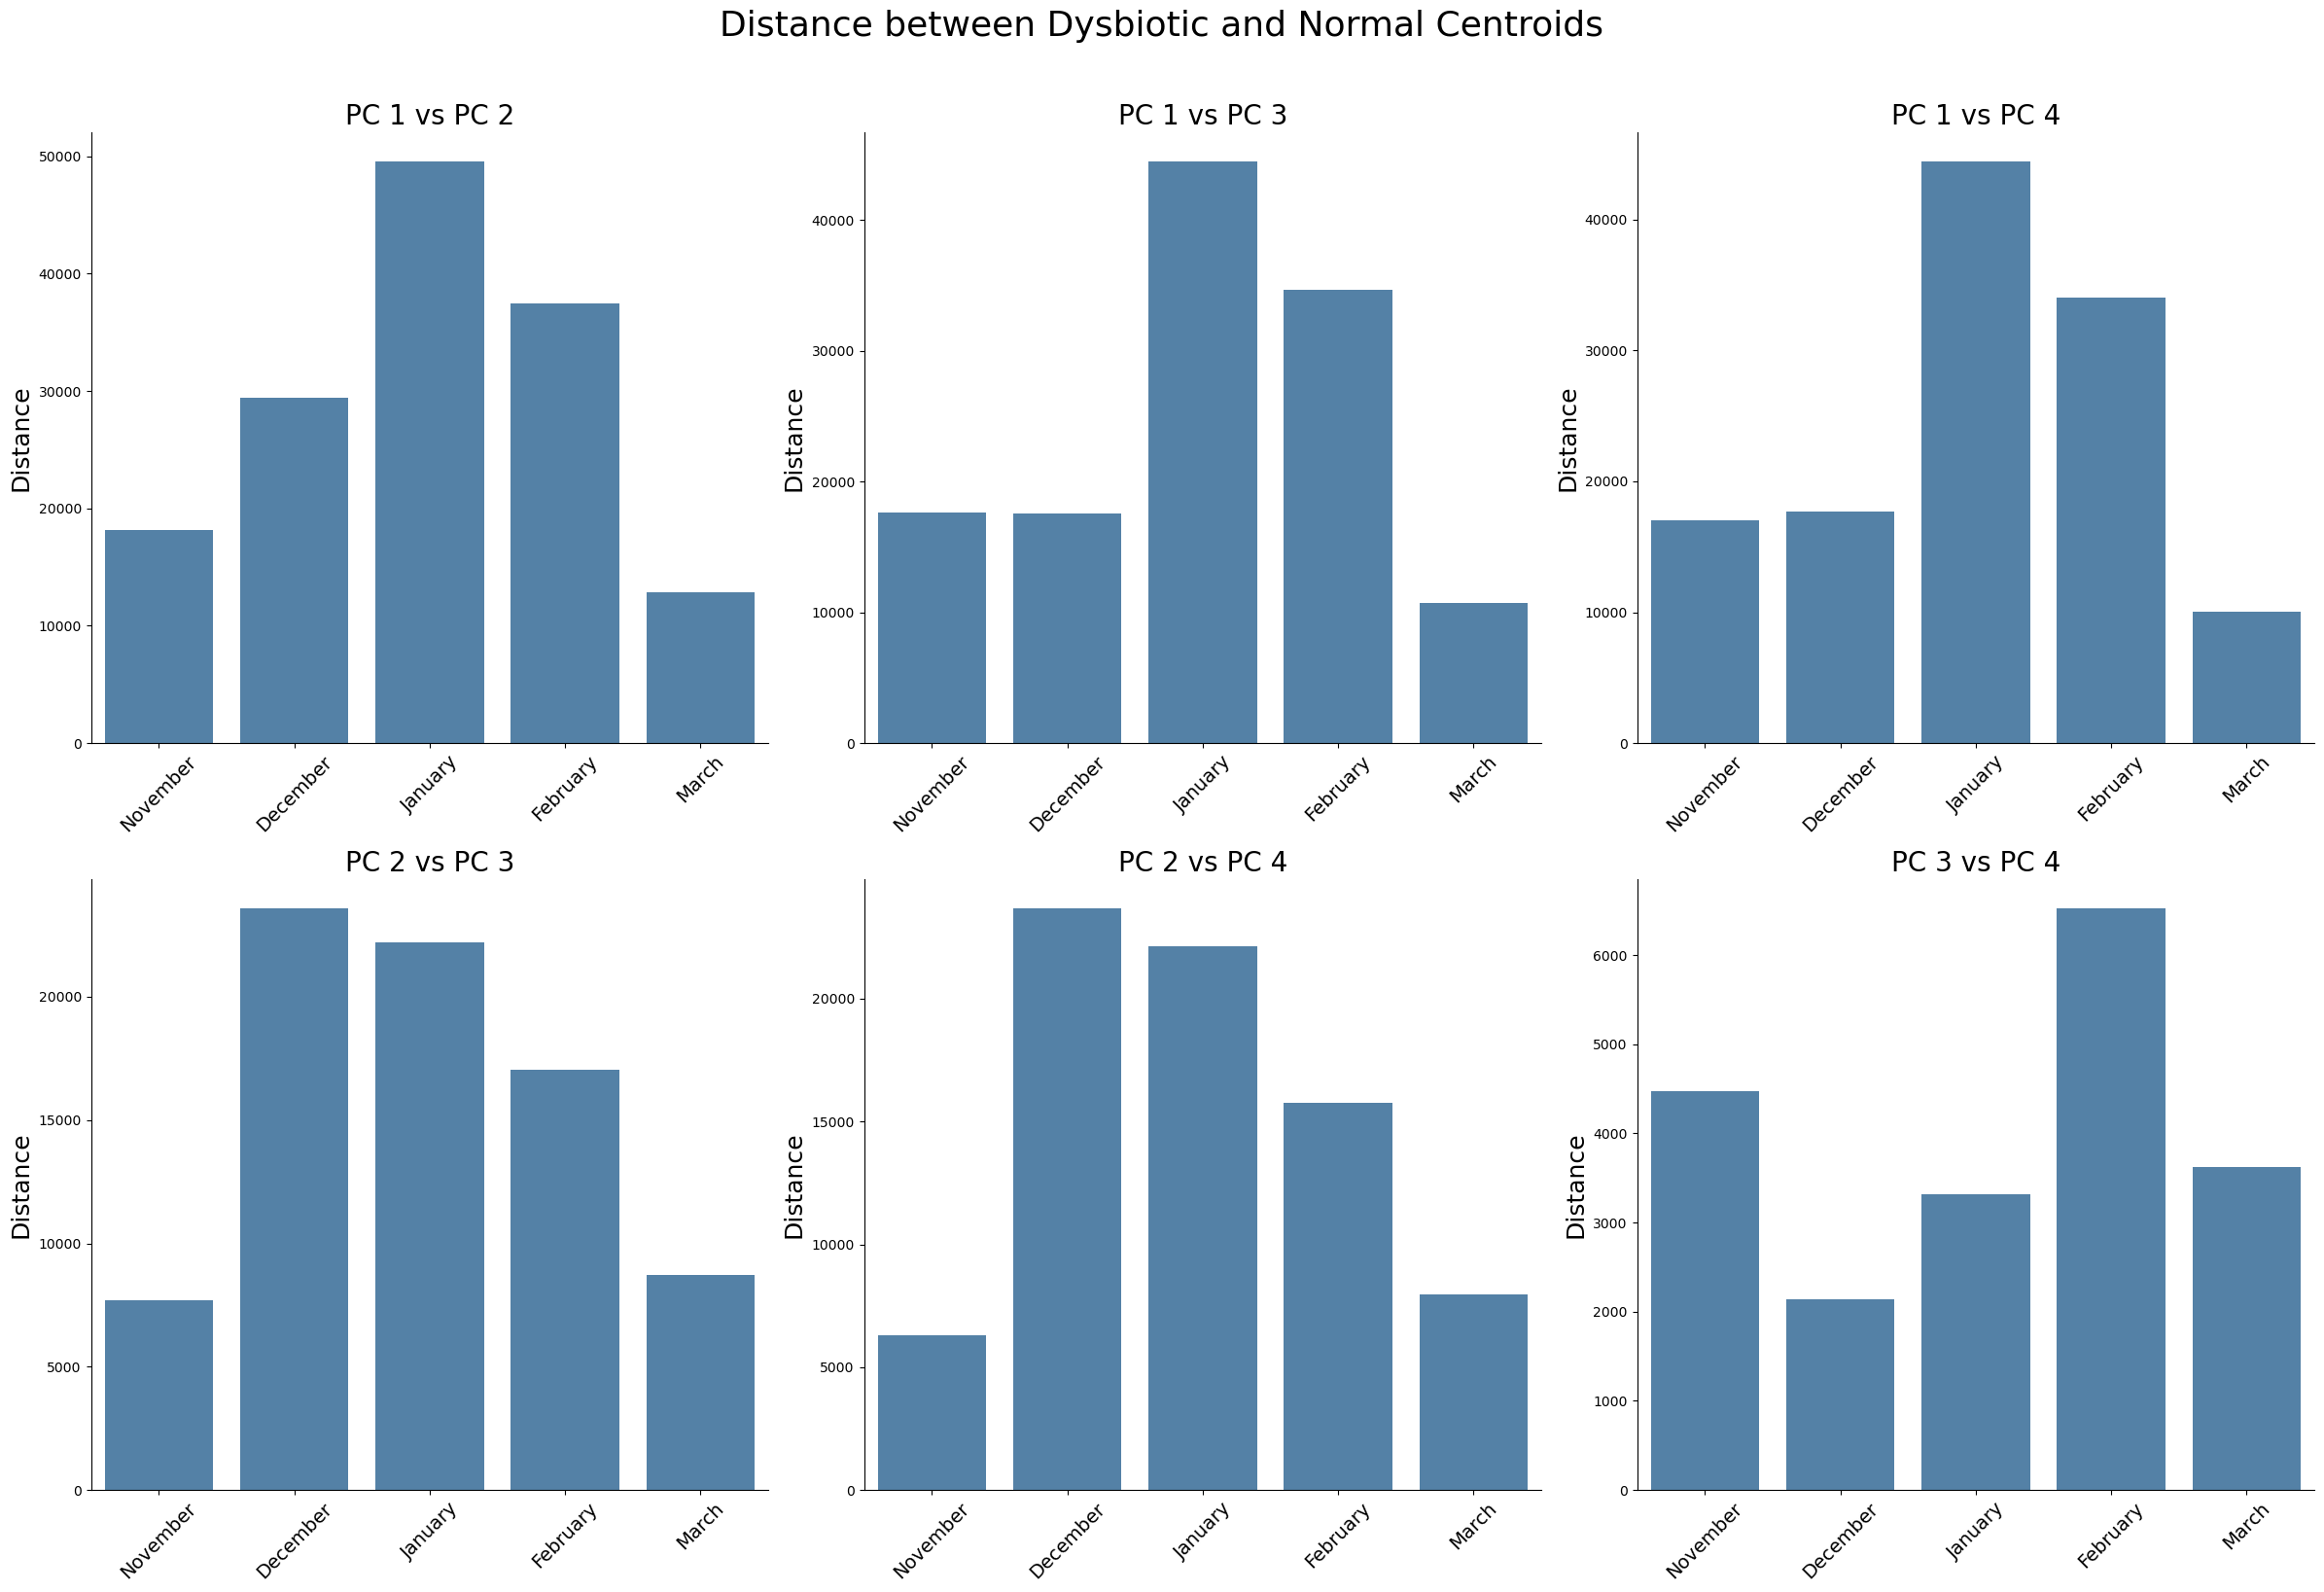

In [20]:
distance_data = []
months = centroids_multi["Sample Month"].unique()

for month in months:
    month_data = centroids_multi[centroids_multi["Sample Month"] == month]

    if (
        "Normal" in month_data["Dysbiosis Status"].values
        and "Dysbiotic" in month_data["Dysbiosis Status"].values
    ):
        normal_centroid = month_data[month_data["Dysbiosis Status"] == "Normal"]
        dysbiotic_centroid = month_data[month_data["Dysbiosis Status"] == "Dysbiotic"]

        for pc_x, pc_y in pairs:
            col_x = f"PC {pc_x}"
            col_y = f"PC {pc_y}"

            x_diff = (
                normal_centroid[col_x].values[0] - dysbiotic_centroid[col_x].values[0]
            )
            y_diff = (
                normal_centroid[col_y].values[0] - dysbiotic_centroid[col_y].values[0]
            )

            dist = np.sqrt(x_diff**2 + y_diff**2)

            distance_data.append(
                {
                    "Sample Month": month,
                    "PC Pair": f"PC {pc_x} vs PC {pc_y}",
                    "Distance": dist,
                }
            )

dist_df = pd.DataFrame(distance_data)

month_order = ["November", "December", "January", "February", "March"]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.patch.set_facecolor("white")
axes = axes.flatten()

for i, (pc_x, pc_y) in enumerate(pairs):
    ax = axes[i]
    pair_name = f"PC {pc_x} vs PC {pc_y}"

    plot_data = dist_df[dist_df["PC Pair"] == pair_name]

    sns.barplot(
        data=plot_data,
        x="Sample Month",
        y="Distance",
        ax=ax,
        color="steelblue",
        order=month_order,
    )

    ax.set_title(pair_name, fontsize=20)
    ax.set_xlabel("", fontsize=18)
    ax.set_ylabel("Distance", fontsize=18)
    ax.tick_params(axis="x", rotation=45, labelsize=14)
    sns.despine(ax=ax)

plt.suptitle("Distance between Dysbiotic and Normal Centroids", fontsize=26, y=1.02)
plt.tight_layout()
plt.show()

In [47]:
# Regress PCA 1 and 2 against total days passed
import statsmodels.api as sm

# We can use the 'daysincestart' from the metadata
pca_df["daysincestart"] = trimmed_metadata["daysincestart"]

X = sm.add_constant(pca_df["daysincestart"])
y1 = pca_df["PCA 1"]
model_pc1 = sm.OLS(y1, X).fit()

y2 = pca_df["PCA 2"]
model_pc2 = sm.OLS(y2, X).fit()

print("Transcriptome PC1 vs Days Since Start:")
print(model_pc1.summary().tables[1])
print("\nTranscriptome PC2 vs Days Since Start:")
print(model_pc2.summary().tables[1])

Transcriptome PC1 vs Days Since Start:
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -9.901e+04   7601.950    -13.024      0.000   -1.14e+05   -8.41e+04
daysincestart  1079.3209     76.756     14.062      0.000     928.456    1230.186

Transcriptome PC2 vs Days Since Start:
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.267e+04   5225.254     -2.425      0.016   -2.29e+04   -2402.678
daysincestart   138.1554     52.758      2.619      0.009      34.458     241.853


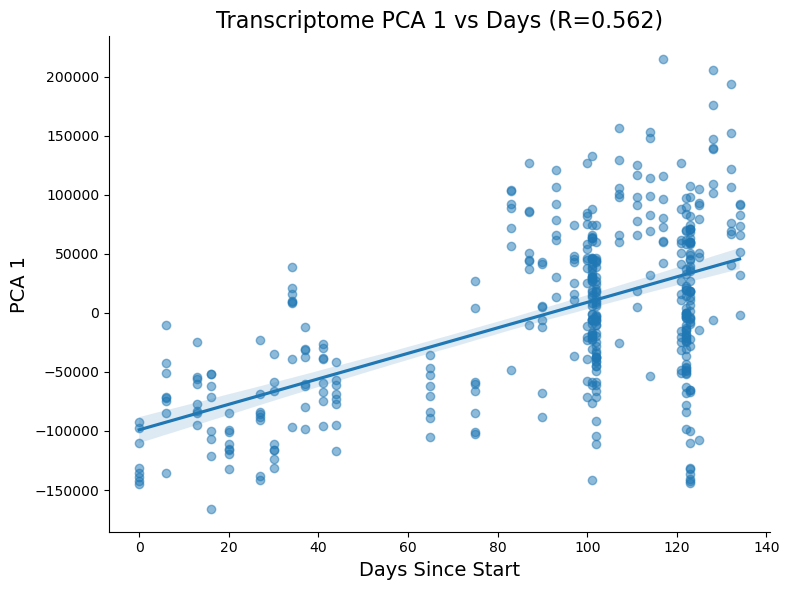

In [48]:
# Plot regressions for Transcriptome PC1 vs daysincestart
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=pca_df, x="daysincestart", y="PCA 1", ax=ax, scatter_kws={"alpha": 0.5}
)
r, _ = stats.pearsonr(pca_df["daysincestart"], pca_df["PCA 1"])
ax.set_title(f"Transcriptome PCA 1 vs Days (R={r:.3f})", fontsize=16)
ax.set_xlabel("Days Since Start", fontsize=14)
ax.set_ylabel("PCA 1", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

In [49]:
# Regress Microbiome PCA 1 and 2 against total days passed
microbiome_pca = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/AT_16S_ord_total.csv"
)

# Drop any rows with NaN in PCs or daysincestart
microbiome_pca = microbiome_pca.dropna(subset=["PC1", "PC2", "daysincestart"])

X_mic = sm.add_constant(microbiome_pca["daysincestart"])
y1_mic = microbiome_pca["PC1"]
model_mic_pc1 = sm.OLS(y1_mic, X_mic).fit()

y2_mic = microbiome_pca["PC2"]
model_mic_pc2 = sm.OLS(y2_mic, X_mic).fit()

print("Microbiome PC1 vs Days Since Start:")
print(model_mic_pc1.summary().tables[1])
print("\nMicrobiome PC2 vs Days Since Start:")
print(model_mic_pc2.summary().tables[1])

Microbiome PC1 vs Days Since Start:
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.1017      0.003    -31.922      0.000      -0.108      -0.095
daysincestart     0.0011   3.22e-05     34.474      0.000       0.001       0.001

Microbiome PC2 vs Days Since Start:
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0111      0.006     -1.795      0.073      -0.023       0.001
daysincestart     0.0001   6.23e-05      1.939      0.053   -1.66e-06       0.000


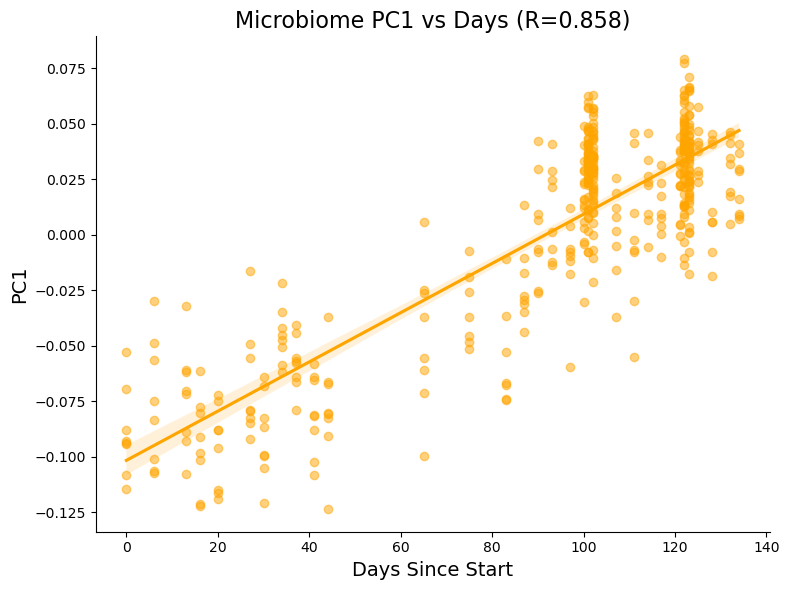

In [50]:
# Plot regressions for Microbiome PC1 vs daysincestart
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=microbiome_pca,
    x="daysincestart",
    y="PC1",
    ax=ax,
    scatter_kws={"alpha": 0.5},
    color="orange",
)
r, _ = stats.pearsonr(microbiome_pca["daysincestart"], microbiome_pca["PC1"])
ax.set_title(f"Microbiome PC1 vs Days (R={r:.3f})", fontsize=16)
ax.set_xlabel("Days Since Start", fontsize=14)
ax.set_ylabel("PC1", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

In [51]:
# Regress PCA 1 and 2 against total days passed, excluding Circadian experiments
# Add Experiment Type to pca_df to filter
pca_df["Experiment Type"] = trimmed_metadata["Experiment Type"]
pca_df_filtered = pca_df[
    ~pca_df["Experiment Type"].isin(
        ["Circadian Experiment 1", "Circadian Experiment 2"]
    )
]

X_filtered = sm.add_constant(pca_df_filtered["daysincestart"])
y1_filtered = pca_df_filtered["PCA 1"]
model_pc1_filtered = sm.OLS(y1_filtered, X_filtered).fit()

y2_filtered = pca_df_filtered["PCA 2"]
model_pc2_filtered = sm.OLS(y2_filtered, X_filtered).fit()

print("Transcriptome PC1 vs Days Since Start (Excluding Circadian):")
print(model_pc1_filtered.summary().tables[1])
print(f"R-squared: {model_pc1_filtered.rsquared:.3f}")

print("\nTranscriptome PC2 vs Days Since Start (Excluding Circadian):")
print(model_pc2_filtered.summary().tables[1])
print(f"R-squared: {model_pc2_filtered.rsquared:.3f}")

Transcriptome PC1 vs Days Since Start (Excluding Circadian):
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.151e+05   6827.789    -16.851      0.000   -1.29e+05   -1.02e+05
daysincestart  1589.2616     80.462     19.752      0.000    1430.691    1747.832
R-squared: 0.638

Transcriptome PC2 vs Days Since Start (Excluding Circadian):
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.461e+04   5077.030     -2.878      0.004   -2.46e+04   -4603.692
daysincestart   117.5403     59.830      1.965      0.051      -0.370     235.451
R-squared: 0.017


In [52]:
# Regress Microbiome PCA 1 and 2 against total days passed, excluding Circadian experiments
microbiome_pca_merged = microbiome_pca.merge(
    metadata[["sampID", "Experiment Type"]],
    left_on="SampleID",
    right_on="sampID",
    how="left",
)
microbiome_pca_filtered = microbiome_pca_merged[
    ~microbiome_pca_merged["Experiment Type"].isin(
        ["Circadian Experiment 1", "Circadian Experiment 2"]
    )
]

# Filter out NaNs if any are leftover
microbiome_pca_filtered = microbiome_pca_filtered.dropna(
    subset=["PC1", "PC2", "daysincestart"]
)

X_mic_filtered = sm.add_constant(microbiome_pca_filtered["daysincestart"])
y1_mic_filtered = microbiome_pca_filtered["PC1"]
model_mic_pc1_filtered = sm.OLS(y1_mic_filtered, X_mic_filtered).fit()

y2_mic_filtered = microbiome_pca_filtered["PC2"]
model_mic_pc2_filtered = sm.OLS(y2_mic_filtered, X_mic_filtered).fit()

print("Microbiome PC1 vs Days Since Start (Excluding Circadian):")
print(model_mic_pc1_filtered.summary().tables[1])
print(f"R-squared: {model_mic_pc1_filtered.rsquared:.3f}")

print("\nMicrobiome PC2 vs Days Since Start (Excluding Circadian):")
print(model_mic_pc2_filtered.summary().tables[1])
print(f"R-squared: {model_mic_pc2_filtered.rsquared:.3f}")

Microbiome PC1 vs Days Since Start (Excluding Circadian):
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.1000      0.003    -33.278      0.000      -0.106      -0.094
daysincestart     0.0010   3.57e-05     26.903      0.000       0.001       0.001
R-squared: 0.751

Microbiome PC2 vs Days Since Start (Excluding Circadian):
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0229      0.006     -3.985      0.000      -0.034      -0.012
daysincestart     0.0005   6.82e-05      7.183      0.000       0.000       0.001
R-squared: 0.177


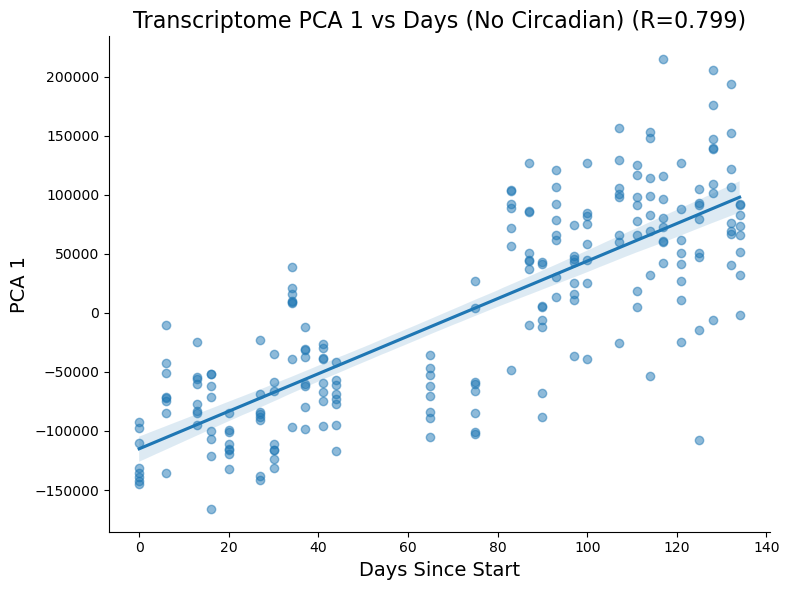

In [53]:
# Plot regressions for Transcriptome PC1 vs daysincestart (excluding Circadian)
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=pca_df_filtered,
    x="daysincestart",
    y="PCA 1",
    ax=ax,
    scatter_kws={"alpha": 0.5},
)
r, _ = stats.pearsonr(pca_df_filtered["daysincestart"], pca_df_filtered["PCA 1"])
ax.set_title(
    f"Transcriptome PCA 1 vs Days (No Circadian) (R={r:.3f})",
    fontsize=16,
)
ax.set_xlabel("Days Since Start", fontsize=14)
ax.set_ylabel("PCA 1", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

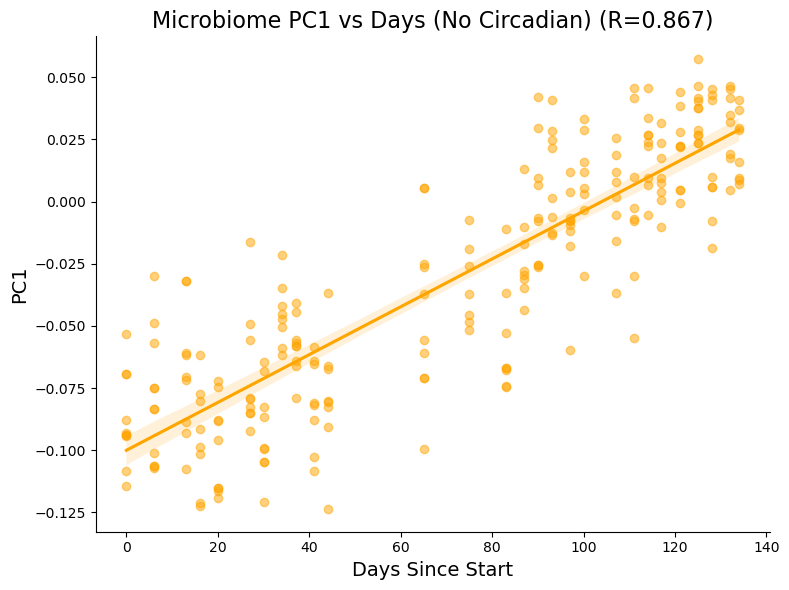

In [54]:
# Plot regressions for Microbiome PC1 vs daysincestart (excluding Circadian)
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=microbiome_pca_filtered,
    x="daysincestart",
    y="PC1",
    ax=ax,
    scatter_kws={"alpha": 0.5},
    color="orange",
)
r, _ = stats.pearsonr(
    microbiome_pca_filtered["daysincestart"], microbiome_pca_filtered["PC1"]
)
ax.set_title(
    f"Microbiome PC1 vs Days (No Circadian) (R={r:.3f})",
    fontsize=16,
)
ax.set_xlabel("Days Since Start", fontsize=14)
ax.set_ylabel("PC1", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

In [44]:
# Redo PCA on transcriptome data excluding Circadian experiments
circadian_experiments = ["Circadian Experiment 1", "Circadian Experiment 2"]
transcriptome_no_circadian_meta = trimmed_metadata[
    ~trimmed_metadata["Experiment Type"].isin(circadian_experiments)
]
transcriptome_no_circadian = trimmed_transcriptome.loc[
    transcriptome_no_circadian_meta.index
]

pca_no_circadian_model = sklearn.decomposition.PCA(n_components=5)
pca_no_circadian = pca_no_circadian_model.fit_transform(transcriptome_no_circadian)

# Create a DataFrame for the new PCA
pca_df_no_circadian = pd.DataFrame(
    pca_no_circadian[:, :2],
    columns=["PCA 1", "PCA 2"],
    index=transcriptome_no_circadian_meta.index,
)
pca_df_no_circadian["Sample Month"] = transcriptome_no_circadian_meta["Sample Month"]
pca_df_no_circadian["Dysbiosis Status"] = transcriptome_no_circadian_meta[
    "Dysbiosis Status"
]
pca_df_no_circadian["daysincestart"] = transcriptome_no_circadian_meta["daysincestart"]

# Run the regression on the new PCA 1
X_new_pca = sm.add_constant(pca_df_no_circadian["daysincestart"])
y1_new_pca = pca_df_no_circadian["PCA 1"]
model_pc1_new_pca = sm.OLS(y1_new_pca, X_new_pca).fit()

print("Recomputed Transcriptome PC1 vs Days Since Start (Excluding Circadian):")
print(model_pc1_new_pca.summary().tables[1])
print(f"R-squared: {model_pc1_new_pca.rsquared:.3f}")

Recomputed Transcriptome PC1 vs Days Since Start (Excluding Circadian):
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.165e+05   6813.772    -17.096      0.000    -1.3e+05   -1.03e+05
daysincestart  1594.3474     80.297     19.856      0.000    1436.102    1752.593
R-squared: 0.641


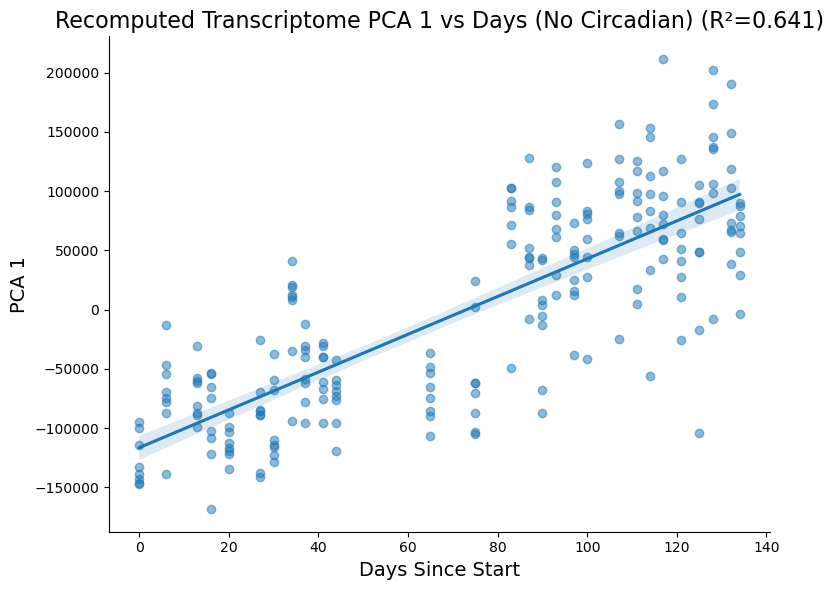

In [ ]:
# Plot regression for Recomputed Transcriptome PC1 vs daysincestart (excluding Circadian)
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=pca_df_no_circadian,
    x="daysincestart",
    y="PCA 1",
    ax=ax,
    scatter_kws={"alpha": 0.5},
)
r, _ = stats.pearsonr(
    pca_df_no_circadian["daysincestart"], pca_df_no_circadian["PCA 1"]
)
ax.set_title(
    f"Recomputed Transcriptome PCA 1 vs Days (No Circadian) (R={r:.3f})",
    fontsize=16,
)
ax.set_xlabel("Days Since Start", fontsize=14)
ax.set_ylabel("PCA 1", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

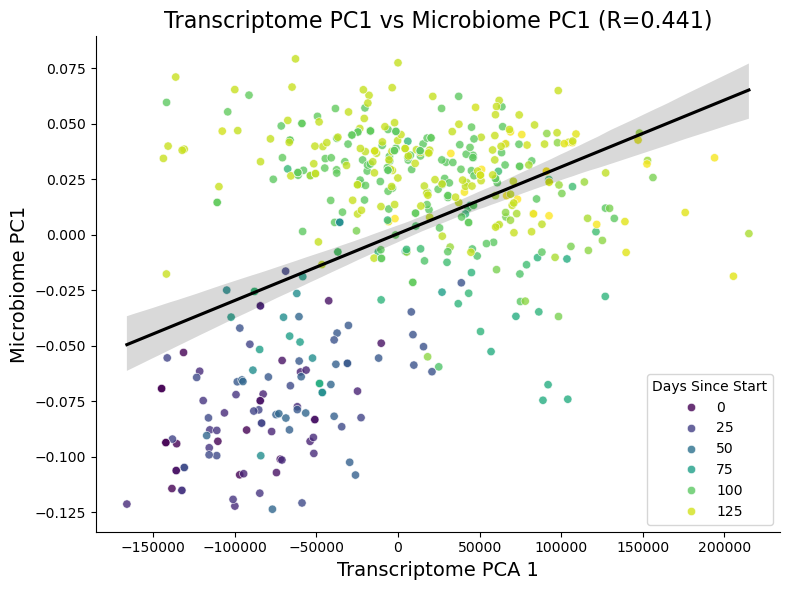

In [58]:
# Plot Transcriptome PC1 vs Microbiome PC1 (With Circadian)
# First we need to merge the PCA dataframes on sampID/SampleID
pca_df["sampID"] = trimmed_metadata["sampID"]
merged_pcas = pca_df.merge(microbiome_pca_merged, left_on="sampID", right_on="SampleID")

fig, ax = plt.subplots(figsize=(8, 6))

# Plot the scatter plot colored by daysincestart_x (created during merge)
sns.scatterplot(
    data=merged_pcas,
    x="PCA 1",
    y="PC1",
    hue="daysincestart_x",
    palette="viridis",
    alpha=0.8,
    ax=ax,
)

# Overlay the regression line
sns.regplot(data=merged_pcas, x="PCA 1", y="PC1", ax=ax, scatter=False, color="black")

# Using dropna just in case to safely compute pearson r
clean_merged = merged_pcas.dropna(subset=["PCA 1", "PC1"])
r_trans_mic, _ = stats.pearsonr(clean_merged["PCA 1"], clean_merged["PC1"])

ax.set_title(f"Transcriptome PC1 vs Microbiome PC1 (R={r_trans_mic:.3f})", fontsize=16)
ax.set_xlabel("Transcriptome PCA 1", fontsize=14)
ax.set_ylabel("Microbiome PC1", fontsize=14)

# Safely set legend title if present
if ax.get_legend() is not None:
    ax.get_legend().set_title("Days Since Start")

sns.despine()
plt.tight_layout()
plt.show()

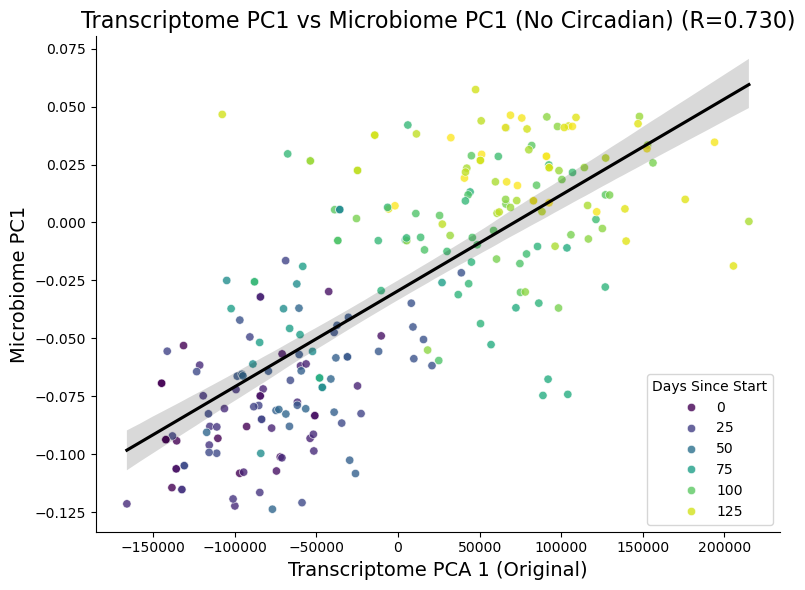

In [59]:
# Plot Transcriptome PC1 vs Microbiome PC1 (Excluding Circadian)
# We use the original transcriptome PCA filtered to exclude circadian samples (pca_df_filtered)
pca_df_filtered = pca_df_filtered.copy()
pca_df_filtered["sampID"] = trimmed_metadata.loc[pca_df_filtered.index, "sampID"]
merged_pcas_no_circadian = pca_df_filtered.merge(
    microbiome_pca_filtered, left_on="sampID", right_on="SampleID"
)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot the scatter plot colored by daysincestart_x (created during merge)
sns.scatterplot(
    data=merged_pcas_no_circadian,
    x="PCA 1",
    y="PC1",
    hue="daysincestart_x",
    palette="viridis",
    alpha=0.8,
    ax=ax,
)

# Overlay the regression line
sns.regplot(
    data=merged_pcas_no_circadian,
    x="PCA 1",
    y="PC1",
    ax=ax,
    scatter=False,
    color="black",
)

clean_merged_nc = merged_pcas_no_circadian.dropna(subset=["PCA 1", "PC1"])
r_trans_mic_nc, _ = stats.pearsonr(clean_merged_nc["PCA 1"], clean_merged_nc["PC1"])

ax.set_title(
    f"Transcriptome PC1 vs Microbiome PC1 (No Circadian) (R={r_trans_mic_nc:.3f})",
    fontsize=16,
)
ax.set_xlabel("Transcriptome PCA 1 (Original)", fontsize=14)
ax.set_ylabel("Microbiome PC1", fontsize=14)

# Safely set legend title if present
if ax.get_legend() is not None:
    ax.get_legend().set_title("Days Since Start")

sns.despine()
plt.tight_layout()
plt.show()